In [1]:
import scanpy as sc

# 读取 .h5ad 文件
adata_all = sc.read("/public/users/xueyupeng/VZV/lvzhu/record/adata_all_celltype_50k.h5ad")

In [2]:
markers = ['CD8_112Cd','CD3_113In',  'CD4_115In', 'CD57_139La', 'CD56_141Pr', 
           'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
           'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
           'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd','TCR-gd_158Gd', 'CD38_159Tb', 
           'CD27_160Gd', 'CD123_161Dy','Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 
           'IL-6_165Ho','MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 
           'CD45RA_170Er','HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb',
       'pSTAT1_175Lu', 'pSTAT3_176Yb',  'CD16_209Bi']

IOStream.flush timed out


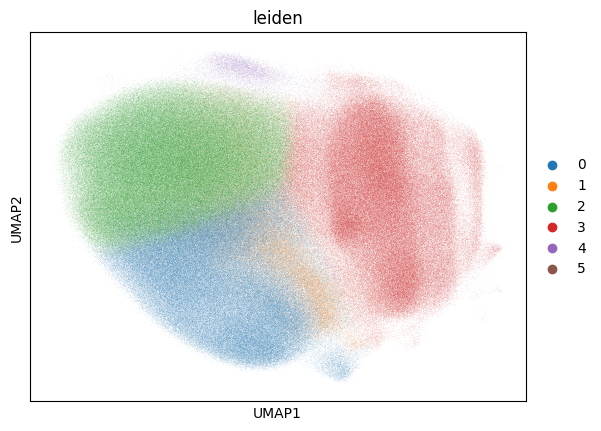

In [4]:
# Filter the AnnData object by specific celltypes  
# 按特定细胞类型过滤 AnnData 对象
celltypes_of_interest = ['NK']

adata_filtered = adata_all[adata_all.obs['celltype'].isin(celltypes_of_interest)].copy()

mask = adata_filtered.var_names.isin(markers)

# Perform PCA (if not already performed)
sc.tl.pca(adata_filtered, svd_solver='arpack', n_comps=30,mask_var=mask)

# Compute the neighborhood graph
sc.pp.neighbors(adata_filtered, n_neighbors=10, use_rep='X_pca')

# Perform UMAP (if not already performed)
sc.tl.umap(adata_filtered)

# Perform clustering (e.g., Leiden clustering)
sc.tl.leiden(
    adata_filtered,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

# You can also visualize the UMAP with Leiden clustering results
sc.pl.umap(adata_filtered, color=['leiden'])

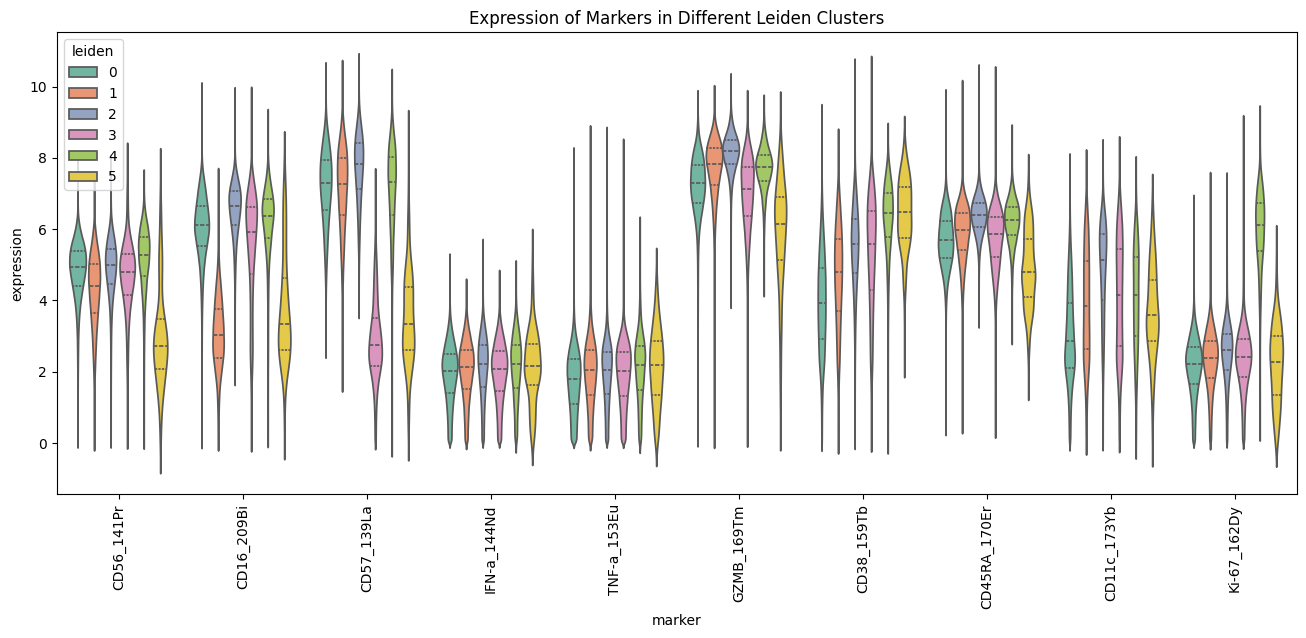

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 选择需要的小提琴图标记物
markers_NK = [
    'CD56_141Pr',  # NK的经典标记
    'CD16_209Bi',  # NK的经典标记
    'CD57_139La',  # 细胞衰老的NK细胞
    'IFN-a_144Nd', # NK的激活和功能
    'TNF-a_153Eu', # NK细胞的细胞因子
    'GZMB_169Tm',  # NK细胞的细胞毒性标志
    'CD38_159Tb',  # NK的活化标记
    'CD45RA_170Er', # NK细胞亚群的标记
    'CD11c_173Yb',
    'Ki-67_162Dy'
]
# 获取标记物的表达数据
data_long = adata_filtered.obs[['leiden']].copy()
for marker in markers_NK:
    data_long[marker] = adata_filtered[:, marker].X.toarray().flatten()  # 获取表达数据并转换为扁平化的数组

# 将数据转换为长格式
data_long = pd.melt(data_long, id_vars=['leiden'], value_vars=markers_NK,
                    var_name='marker', value_name='expression')

# 绘制小提琴图
plt.figure(figsize=(16, 6))
sns.violinplot(x='marker', y='expression', hue='leiden', data=data_long, split=False, inner="quart",
               palette="Set2", dodge=True)
plt.xticks(rotation=90)
plt.title("Expression of Markers in Different Leiden Clusters")
plt.show()

In [6]:
# 统计每个cluster的细胞数
cluster_counts = adata_filtered.obs['leiden'].value_counts()

# 显示结果
print(cluster_counts)

leiden
2    400300
3    356542
0    301896
1     81385
4     12104
5       338
Name: count, dtype: int64


In [13]:
import scanpy as sc
import pandas as pd

# 1. 计算差异表达基因（使用t-test，其他方法如 'wilcoxon' 或 'logreg' 可选）
sc.tl.rank_genes_groups(adata_filtered, groupby='leiden', groups=['0','1', '2','4'], method='t-test', corr_method='benjamini-hochberg')

# 2. 获取结果并转换为DataFrame
result = adata_filtered.uns['rank_genes_groups']
gene_names = result['names']['0']  # '0'代表cluster0，'2'代表cluster2

# 获取对数变化（log fold change）、p值、校正后的p值等信息
logfoldchanges = result['logfoldchanges']['0']
pvals = result['pvals']['0']
pvals_adj = result['pvals_adj']['0']

# 创建DataFrame来展示差异表达基因及其对应的统计信息
marker_df = pd.DataFrame({
    'gene': gene_names,
    'logfoldchanges': logfoldchanges,
    'pvals': pvals,
    'pvals_adj': pvals_adj
})

# 3. 筛选显著差异表达基因（例如，p值小于0.05）
significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

# 4. 查看差异表达基因
print(significant_markers)

                gene  logfoldchanges          pvals      pvals_adj
0         CD57_139La        2.271227   0.000000e+00   0.000000e+00
1             Center        0.799689   0.000000e+00   0.000000e+00
2         CD16_209Bi        0.387486   0.000000e+00   0.000000e+00
3           Residual        0.536055   0.000000e+00   0.000000e+00
4             Offset        0.597306   0.000000e+00   0.000000e+00
5          CD8_112Cd        0.410200   0.000000e+00   0.000000e+00
6               Time        0.271398   0.000000e+00   0.000000e+00
7       CD45-1_106Cd        0.558529   0.000000e+00   0.000000e+00
8       CD45-2_110Cd        0.476488   0.000000e+00   0.000000e+00
9       CD45-4_114Cd        0.320834   0.000000e+00   0.000000e+00
10        CD14_155Gd        0.262492   0.000000e+00   0.000000e+00
11         CD3_113In        0.139057   0.000000e+00   0.000000e+00
12        CD56_141Pr        0.128247   0.000000e+00   0.000000e+00
13      Event_Length        0.019938  6.856169e-196  7.750452e

In [9]:
# 2. 获取结果并转换为DataFrame
result = adata_filtered.uns['rank_genes_groups']
gene_names = result['names']['2']  # '0'代表cluster0，'2'代表cluster2

# 获取对数变化（log fold change）、p值、校正后的p值等信息
logfoldchanges = result['logfoldchanges']['2']
pvals = result['pvals']['2']
pvals_adj = result['pvals_adj']['2']

# 创建DataFrame来展示差异表达基因及其对应的统计信息
marker_df = pd.DataFrame({
    'gene': gene_names,
    'logfoldchanges': logfoldchanges,
    'pvals': pvals,
    'pvals_adj': pvals_adj
})

# 3. 筛选显著差异表达基因（例如，p值小于0.05）
significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

# 4. 查看差异表达基因
print(significant_markers)

                gene  logfoldchanges          pvals      pvals_adj
0         CD57_139La        3.720751   0.000000e+00   0.000000e+00
1         GZMB_169Tm        1.429198   0.000000e+00   0.000000e+00
2                CSR        0.307405   0.000000e+00   0.000000e+00
3       CD45RA_170Er        0.928581   0.000000e+00   0.000000e+00
4         CD16_209Bi        1.569334   0.000000e+00   0.000000e+00
5       pSTAT3_176Yb        1.013020   0.000000e+00   0.000000e+00
6         STC1_168Er        1.274161   0.000000e+00   0.000000e+00
7         CD14_155Gd        2.255836   0.000000e+00   0.000000e+00
8      H3K27ac_148Nd        0.751147   0.000000e+00   0.000000e+00
9        CD11c_173Yb        1.802463   0.000000e+00   0.000000e+00
10  Arginase-1_164Dy        1.071809   0.000000e+00   0.000000e+00
11         pS6_151Eu        0.626214   0.000000e+00   0.000000e+00
12       MCP-1_166Er        1.008572   0.000000e+00   0.000000e+00
13      CASP-8_156Gd        0.666867   0.000000e+00   0.000000

In [12]:
# 2. 获取结果并转换为DataFrame
result = adata_filtered.uns['rank_genes_groups']
gene_names = result['names']['1']  # '0'代表cluster0，'2'代表cluster2

# 获取对数变化（log fold change）、p值、校正后的p值等信息
logfoldchanges = result['logfoldchanges']['1']
pvals = result['pvals']['1']
pvals_adj = result['pvals_adj']['1']

# 创建DataFrame来展示差异表达基因及其对应的统计信息
marker_df = pd.DataFrame({
    'gene': gene_names,
    'logfoldchanges': logfoldchanges,
    'pvals': pvals,
    'pvals_adj': pvals_adj
})

# 3. 筛选显著差异表达基因（例如，p值小于0.05）
significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

# 4. 查看差异表达基因
print(significant_markers)

             gene  logfoldchanges          pvals      pvals_adj
0      CD57_139La        1.717866   0.000000e+00   0.000000e+00
1     IFN-g_172Yb        0.500458   0.000000e+00   0.000000e+00
2     MCP-1_166Er        0.379204   0.000000e+00   0.000000e+00
3      CD14_155Gd        0.471337   0.000000e+00   0.000000e+00
4      LIVE_198Pt        0.207216   0.000000e+00   0.000000e+00
5      GZMB_169Tm        0.223943   0.000000e+00   0.000000e+00
6     TNF-a_153Eu        0.216803  7.916221e-287  2.286908e-286
7      STC1_168Er        0.123348  4.317157e-117  8.017577e-117
8    CASP-8_156Gd        0.085449   9.673440e-98   1.734548e-97
9    CD45-3_111Cd        0.154544   3.137342e-44   4.409237e-44
10      IgD_142Nd        0.049036   2.538677e-22   3.070028e-22
11    IFN-a_144Nd        0.017405   4.191054e-04   4.636911e-04
12     IL-6_165Ho        0.009819   2.615135e-02   2.775245e-02
16    CD123_161Dy       -0.011166   1.173332e-02   1.271110e-02
17   CD45-2_110Cd       -0.084750   1.22

In [14]:
# 2. 获取结果并转换为DataFrame
result = adata_filtered.uns['rank_genes_groups']
gene_names = result['names']['4']  # '0'代表cluster0，'2'代表cluster2

# 获取对数变化（log fold change）、p值、校正后的p值等信息
logfoldchanges = result['logfoldchanges']['4']
pvals = result['pvals']['4']
pvals_adj = result['pvals_adj']['4']

# 创建DataFrame来展示差异表达基因及其对应的统计信息
marker_df = pd.DataFrame({
    'gene': gene_names,
    'logfoldchanges': logfoldchanges,
    'pvals': pvals,
    'pvals_adj': pvals_adj
})

# 3. 筛选显著差异表达基因（例如，p值小于0.05）
significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

# 4. 查看差异表达基因
print(significant_markers)

                gene  logfoldchanges          pvals      pvals_adj
0        Ki-67_162Dy        5.353652   0.000000e+00   0.000000e+00
1         CD38_159Tb        1.954194   0.000000e+00   0.000000e+00
2      H3K27ac_148Nd        0.703558   0.000000e+00   0.000000e+00
3       HLA-DR_171Yb        2.107366   0.000000e+00   0.000000e+00
4                CSR        0.261609   0.000000e+00   0.000000e+00
5         CD57_139La        1.575380   0.000000e+00   0.000000e+00
6          pS6_151Eu        0.512837   0.000000e+00   0.000000e+00
7        MCP-1_166Er        0.840725   0.000000e+00   0.000000e+00
8       pSTAT3_176Yb        0.486610   0.000000e+00   0.000000e+00
9   Arginase-1_164Dy        0.720412   0.000000e+00   0.000000e+00
10        IL-4_154Sm        0.493312   0.000000e+00   0.000000e+00
11        STC1_168Er        0.554664   0.000000e+00   0.000000e+00
12        CD56_141Pr        0.538871   0.000000e+00   0.000000e+00
13      CD45RA_170Er        0.349050   0.000000e+00   0.000000

In [16]:
cluster_anno = {
    "0": "NK_CD11c-",
    "1": "NKbright",
    "2": "NK_CD11c+",
    "3": "NK_CD57-",
    "4": "NK_Ki67+",
    "5": "unknown"
}

In [19]:
adata_filtered.obs["subtype"] = adata_filtered.obs["leiden"].map(cluster_anno)

In [29]:
cell_info_df = pd.DataFrame({
    'cellid': adata_filtered.obs.index,  # 细胞ID
    'sample': adata_filtered.obs['Sample'],  # 样本ID
    'celltype': adata_filtered.obs['celltype'],  # 细胞类型
    'subtype': adata_filtered.obs['subtype'] # 细胞亚型  
})
cell_info_df.head()
cell_info_df.to_csv('/public/users/xueyupeng/VZV/lvzhu/record/subtype_annotations_NK.csv', index=False)

In [21]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 输出目录 =========
base_dir = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/"
dir1 = os.path.join(base_dir, "1_threshold_distribution_NK")
dir2 = os.path.join(base_dir, "2_positive_ratio_NK")
dir3 = os.path.join(base_dir, "3_positive_median_NK")
dir4 = os.path.join(base_dir, "4_positive_geomean_NK")

for d in [dir1, dir2, dir3, dir4]:
    os.makedirs(d, exist_ok=True)

# ========= 参数 =========
sub_markers = ['IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
               'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
               'IL-4_154Sm', 'CASP-8_156Gd','CD38_159Tb', 'CD123_161Dy','Ki-67_162Dy', 
               'CXCL10_163Dy', 'Arginase-1_164Dy', 'IL-6_165Ho','MCP-1_166Er', 
               'CD69_167Er', 'STC1_168Er', 'IFN-g_172Yb','pSTAT1_175Lu', 'pSTAT3_176Yb']


timepoints = sorted(adata_filtered.obs['Timepoint'].unique())
subtypes = sorted(adata_filtered.obs['subtype'].unique())

# ========= 1️⃣ 计算阈值 =========
v1day0_idx = (adata_filtered.obs['Timepoint'] == 'V1Day0')
marker_stats = {}

for ct in subtypes:
    ct_idx = v1day0_idx & (adata_filtered.obs['subtype'] == ct)
    for marker in sub_markers:
        if marker not in adata_filtered.var_names:
            continue
        idx_marker = adata_filtered.var_names.get_loc(marker)
        data_vec = adata_filtered[ct_idx, idx_marker].X
        data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

        median = np.median(data_vec)
        sd = np.std(data_vec)
        marker_stats[(ct, marker)] = median + 2*sd

# ========= 2️⃣ 统计 =========
records = []

for ct in subtypes:
    for marker in sub_markers:
        if (ct, marker) not in marker_stats:
            continue

        idx_marker = adata_filtered.var_names.get_loc(marker)
        threshold = marker_stats[(ct, marker)]

        for sample in adata_filtered.obs['Sample'].unique():
            for tp in timepoints:

                mask = (
                    (adata_filtered.obs['Sample'] == sample) &
                    (adata_filtered.obs['Timepoint'] == tp) &
                    (adata_filtered.obs['subtype'] == ct)
                )

                if mask.sum() == 0:
                    continue

                data_vec = adata_filtered[mask, idx_marker].X
                data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

                pos = data_vec[data_vec > threshold]

                pos_ratio = len(pos) / len(data_vec) * 100

                pos_median = np.median(pos) if len(pos) > 0 else np.nan

                # 几何平均数（避免0）
                pos_geomean = np.exp(np.mean(np.log(pos + 1e-9))) if len(pos) > 0 else np.nan

                records.append({
                    "Sample": sample,
                    "Timepoint": tp,
                    "subtype": ct,
                    "Marker": marker,
                    "Positive_Ratio_%": pos_ratio,
                    "Positive_Median": pos_median,
                    "Positive_Geomean": pos_geomean
                })

marker_summary = pd.DataFrame(records)

In [22]:
# ========= 保存路径 =========
save_dir = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/"
os.makedirs(save_dir, exist_ok=True)

# ========= 1️⃣ 保存 marker_summary =========
marker_summary_path = os.path.join(save_dir, "marker_summary_subtype.csv")
marker_summary.to_csv(marker_summary_path, index=False)
print(f"✓ marker_summary 已保存: {marker_summary_path}")

# ========= 2️⃣ 保存阈值表 =========
# dict → DataFrame
threshold_df = pd.DataFrame([
    {
        "subtype": ct,
        "Marker": marker,
        "Threshold": thresh
    }
    for (ct, marker), thresh in marker_stats.items()
])

threshold_path = os.path.join(save_dir, "marker_thresholds_subtype.csv")
threshold_df.to_csv(threshold_path, index=False)
print(f"✓ 阈值表已保存: {threshold_path}")

# ========= 3️⃣ 基本信息检查 =========
print("\n=== 数据概览 ===")
print("marker_summary shape:", marker_summary.shape)
print("threshold_df shape:", threshold_df.shape)

print("\n=== marker_summary 前5行 ===")
print(marker_summary.head())

print("\n=== threshold_df 前5行 ===")
print(threshold_df.head())

✓ marker_summary 已保存: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/marker_summary_subtype.csv
✓ 阈值表已保存: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/marker_thresholds_subtype.csv

=== 数据概览 ===
marker_summary shape: (20976, 7)
threshold_df shape: (144, 3)

=== marker_summary 前5行 ===
    Sample Timepoint    subtype     Marker  Positive_Ratio_%  Positive_Median  \
0  A004_V1    V1Day1  NK_CD11c+  IgD_142Nd          0.308642         3.977386   
1  A007_V0    V1Day0  NK_CD11c+  IgD_142Nd          3.585657         3.704853   
2  A016_V1    V1Day1  NK_CD11c+  IgD_142Nd          0.000000              NaN   
3  A007_V3    V2Day0  NK_CD11c+  IgD_142Nd          1.840491         3.937123   
4  A005_V4    V2Day1  NK_CD11c+  IgD_142Nd          1.226994         3.887733   

   Positive_Geomean  
0          4.295293  
1          3.940521  
2               NaN  
3          4.156166  
4          3.879636  

=== threshold_df 前5行 ===
     subtype         Marker  Threshold
0  NK_CD11c+     

In [23]:
# ========= 图1：阈值分布（按 subtype） =========
for ct in subtypes:
    for marker in sub_markers:

        if marker not in adata_filtered.var_names:
            continue
        if (ct, marker) not in marker_stats:
            continue

        idx_marker = adata_filtered.var_names.get_loc(marker)
        threshold = marker_stats[(ct, marker)]

        plt.figure(figsize=(6,5))

        # 每个 sample 一条曲线
        for sample in adata_filtered.obs['Sample'].unique():
            mask = (
                (adata_filtered.obs['Sample'] == sample) &
                (adata_filtered.obs['subtype'] == ct)
            )

            if mask.sum() == 0:
                continue

            data_vec = adata_filtered[mask, idx_marker].X
            data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

            # 防止全0或常数导致kde报错
            if np.std(data_vec) == 0:
                continue

            sns.kdeplot(data_vec, alpha=0.3)

        # 🔴 阈值线
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2)

        plt.title(f"{marker} ({ct})")
        plt.xlabel("Expression")
        plt.ylabel("Density")

        plt.legend([],[],frameon=False)
        plt.tight_layout()

        plt.savefig(f"{dir1}/{marker}_{ct}_distribution.png", dpi=300)
        plt.close()

In [24]:
def plot_box_scatter(df, y, ylabel, save_dir, marker, ct):

    # ❗ 固定时间顺序
    timepoint_order = ["V1Day0", "V1Day1", "V2Day0", "V2Day1"]

    # ❗ 去掉 NaN
    df = df.dropna(subset=[y])

    # ❗ 只保留定义顺序中的时间点
    df = df[df["Timepoint"].isin(timepoint_order)]

    # ❗ 每个 timepoint 至少2个点
    valid_counts = df.groupby("Timepoint")[y].count()
    if (valid_counts < 2).any():
        return

    # ❗ log轴不能有0或负值
    df = df[df[y] > 0]
    if df.shape[0] < 3:
        return

    plt.figure(figsize=(6,5))

    # ✅ 箱线图
    sns.boxplot(
        data=df,
        x="Timepoint",
        y=y,
        order=timepoint_order,   # ⭐ 固定顺序
        color="lightgray",
        showfliers=False
    )

    # ✅ 散点
    sns.stripplot(
        data=df,
        x="Timepoint",
        y=y,
        order=timepoint_order,
        hue="Sample",
        dodge=False,
        size=5,
        alpha=0.8,
        jitter=True
    )

    # ✅ log 轴
    plt.yscale("log")

    plt.ylabel(ylabel + " (log scale)")
    plt.xlabel("Timepoint")
    plt.title(f"{marker} ({ct})")

    # 去掉图例
    plt.legend([], [], frameon=False)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{marker}_{ct}.png", dpi=300)
    plt.close()

In [25]:
for ct in subtypes:
    for marker in sub_markers:

        df = marker_summary[
            (marker_summary["Marker"] == marker) &
            (marker_summary["subtype"] == ct)
        ]

        if df.empty:
            continue

        # 图2：阳性比例
        plot_box_scatter(df, "Positive_Ratio_%", "Positive Ratio (%)", dir2, marker, ct)

        # 图3：阳性中位数
        plot_box_scatter(df, "Positive_Median", "Median Expression", dir3, marker, ct)

        # 图4：几何平均数
        plot_box_scatter(df, "Positive_Geomean", "Geometric Mean", dir4, marker, ct)

print("✅ 全部图片已保存")

✅ 全部图片已保存


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import os
import re

# ========= 从 Sample 提取 ID =========
def extract_id(sample):
    # A004_V3 -> A004
    return re.sub(r"_V\d+$", "", sample)

# 添加 ID 列
marker_summary["ID"] = marker_summary["Sample"].apply(extract_id)

# ========= 参数 =========
timepoint_pairs = [
    ("V1Day0", "V1Day1"),
    ("V2Day0", "V2Day1")
]

alpha = 0.05
results = []

# ========= 主循环 =========
subtypes = marker_summary["subtype"].dropna().unique()
markers = marker_summary["Marker"].dropna().unique()

for ct in subtypes:
    for marker in markers:

        df = marker_summary[
            (marker_summary["subtype"] == ct) &
            (marker_summary["Marker"] == marker)
        ]

        if df.empty:
            continue

        for tp1, tp2 in timepoint_pairs:

            df1 = df[df["Timepoint"] == tp1]
            df2 = df[df["Timepoint"] == tp2]

            if df1.empty or df2.empty:
                continue

            # ========= 用 ID 配对 =========
            common_IDs = set(df1["ID"]).intersection(set(df2["ID"]))

            if len(common_IDs) < 3:
                continue

            df1_id = df1[df1["ID"].isin(common_IDs)].set_index("ID")
            df2_id = df2[df2["ID"].isin(common_IDs)].set_index("ID")

            df1_id = df1_id.sort_index()
            df2_id = df2_id.sort_index()

            for metric in ["Positive_Ratio_%", "Positive_Median", "Positive_Geomean"]:

                if metric not in df.columns:
                    continue

                x = df1_id[metric]
                y = df2_id[metric]

                common = x.index.intersection(y.index)

                if len(common) < 3:
                    continue

                x = x.loc[common].dropna()
                y = y.loc[common].dropna()

                # 再次对齐
                common = x.index.intersection(y.index)
                x = x.loc[common]
                y = y.loc[common]

                if len(x) < 3:
                    continue

                # 跳过无变化
                if np.all(x == y):
                    continue

                # 跳过常数
                if x.nunique() < 2 or y.nunique() < 2:
                    continue

                try:
                    stat, p = wilcoxon(x, y)
                except Exception:
                    continue

                results.append({
                    "subtype": ct,
                    "Marker": marker,
                    "Comparison": f"{tp1} vs {tp2}",
                    "Metric": metric,
                    "N": len(common),
                    "Mean_1": x.mean(),
                    "Mean_2": y.mean(),
                    "Median_1": x.median(),
                    "Median_2": y.median(),
                    "p_value": p
                })

# ========= 转 DataFrame =========
results_df = pd.DataFrame(results)

print(f"Total valid tests: {len(results_df)}")

# ========= FDR 校正 =========
if not results_df.empty and "p_value" in results_df.columns:
    results_df["p_adj"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
    results_df = results_df.sort_values("p_adj")
    results_sig = results_df[results_df["p_adj"] < alpha]
else:
    print("⚠️ 没有任何统计结果（请检查数据）")
    results_df["p_adj"] = []
    results_sig = results_df.copy()



Total valid tests: 704
✓ 保存完成: /public/users/xueyupeng/VZV/lvzhu/record/significant_markers_with_FDR.xlsx
✓ 总结果数: 704
✓ 显著结果数 (FDR < 0.05): 8


In [28]:
# ========= 保存 =========
save_path = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/significant_markers_with_FDR.xlsx"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="all_results", index=False)
    results_sig.to_excel(writer, sheet_name="significant_only", index=False)

print(f"✓ 保存完成: {save_path}")
print(f"✓ 总结果数: {len(results_df)}")
print(f"✓ 显著结果数 (FDR < {alpha}): {len(results_sig)}")

✓ 保存完成: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_NK/significant_markers_with_FDR.xlsx
✓ 总结果数: 704
✓ 显著结果数 (FDR < 0.05): 8


In [27]:
print(results_df)

       subtype         Marker        Comparison            Metric   N  \
413   NK_CD57-    IFN-g_172Yb  V2Day0 vs V2Day1  Positive_Ratio_%  39   
401   NK_CD57-     CD69_167Er  V2Day0 vs V2Day1  Positive_Ratio_%  39   
261  NK_CD11c-     CD69_167Er  V2Day0 vs V2Day1  Positive_Ratio_%  39   
415   NK_CD57-    IFN-g_172Yb  V2Day0 vs V2Day1  Positive_Geomean  34   
644   NKbright     CD69_167Er  V2Day0 vs V2Day1  Positive_Ratio_%  39   
..         ...            ...               ...               ...  ..   
438   NK_Ki67+    CXCL9_146Nd  V1Day0 vs V1Day1  Positive_Geomean   4   
313   NK_CD57-  H3K27ac_148Nd  V1Day0 vs V1Day1   Positive_Median  10   
437   NK_Ki67+    CXCL9_146Nd  V1Day0 vs V1Day1   Positive_Median   4   
107  NK_CD11c+     IL-6_165Ho  V2Day0 vs V2Day1  Positive_Geomean  27   
459   NK_Ki67+   4E-BP1_150Nd  V1Day0 vs V1Day1   Positive_Median   3   

       Mean_1    Mean_2  Median_1  Median_2       p_value     p_adj  
413  3.053702  0.926213  2.005231  0.310982  2.759043